# Downloading and plotting Copernicus data with Python

First, create a virtual environment: 
`conda create --name bioc26` 

and activate it:
`conda activate bioc26`

Within this virtual environment, we can now install the libraries needed:
`conda install matplotlib xarray netCDF4 numpy pandas cartopy jupyter copernicusmarine`

To deactivate the virtual environment (e.g., end of the day), do `conda deactivate`. 


When selecting the kernel in VS code, make sure to select 'bioc26'. 

In the reminal, run `copernicusmarine login` to store your login credentials, which is needed later for the data download.

## Loading libraries and data

In [2]:
%pip install matplotlib xarray netCDF4 numpy cartopy

# load libraries

from datetime import timedelta as delta
from glob import glob

import matplotlib.pyplot as plt
import xarray as xr

import netCDF4 as nc
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='50m', edgecolor='k', facecolor=cfeature.COLORS['land'])
# ocean = cfeature.NaturalEarthFeature('physical', 'ocean', \
#     scale='50m', edgecolor='w', facecolor=cfeature.COLORS['water'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 23.5 MB/s  0:00:00eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pyshp-3.0.12-py3-none-any.whl.metadata (69 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 36.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 20.7 MB/s  0:00:01 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 37.0 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 22.3 MB/s  0:00:00
Using cached pyshp-3.0.12-py3-none-any.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# create data directory
import os

os.makedirs('data', exist_ok=True)

## Downloading Copernicus data

Additional to using the Copernicus website, you can also download data programmatically using the copernicusmarine API. 
Via the website, you can also create the python command based on your pre selection of data and paste it below. 
In this example, we download a Level 3 data product of total and plankton functional type (PFT) chlorophyll concentrations. 

In [ ]:
# load physical data

import copernicusmarine

# for this to work, install copernicusmarine toolbox first (either with pip or conda) and run `copernicusmarine login` 
# in the terminal to store your login credentials

dsname = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"

# if data with dsname does not exist on your drive, download it (takes long, large file)
if not glob(f"data/{dsname}.nc"):
  copernicusmarine.subset(
  dataset_id=f"{dsname}",
    minimum_longitude=9,
    maximum_longitude=11,
    minimum_latitude=54.0,
    maximum_latitude=55.5,
    start_datetime="2026-06-01T00:00:00",
    end_datetime="2026-06-18T00:00:00",
    disable_progress_bar=False,
    output_filename = f"{dsname}.nc",
    output_directory = "data"
  )




In [ ]:
# load data (into your workspace)

chl_ds = xr.open_dataset(f"data/{dsname}.nc")

In [ ]:
# inspect: 

chl_ds

<xarray.Dataset> Size: 2MB
Dimensions:              (time: 10, latitude: 36, longitude: 48)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2026-06-01 ... 2026-06-10
  * latitude             (latitude) float32 144B 54.02 54.06 ... 55.44 55.48
  * longitude            (longitude) float32 192B 9.021 9.063 ... 10.94 10.98
Data variables: (12/21)
    CHL                  (time, latitude, longitude) float32 69kB ...
    CHL_uncertainty      (time, latitude, longitude) float64 138kB ...
    DIATO                (time, latitude, longitude) float32 69kB ...
    DIATO_uncertainty    (time, latitude, longitude) float64 138kB ...
    DINO                 (time, latitude, longitude) float32 69kB ...
    DINO_uncertainty     (time, latitude, longitude) float64 138kB ...
    ...                   ...
    PICO_uncertainty     (time, latitude, longitude) float64 138kB ...
    PROCHLO              (time, latitude, longitude) float32 69kB ...
    PROCHLO_uncertainty  (time, latitude, longitude) float64 138kB ...
    PROKAR               (time, latitude, longitude) float32 69kB ...
    PROKAR_uncertainty   (time, latitude, longitude) float64 138kB ...
    flags                (time, latitude, longitude) int8 17kB ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_resolution:        P1D
    time_coverage_start:             2026-03-01T19:48:26Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0
    copernicusmarine_version:        2.4.1

In [ ]:
# look at CHL variable: (first time step, all lat and lon)

chl_ds.CHL[0,:,:]

<xarray.DataArray 'CHL' (latitude: 36, longitude: 48)> Size: 7kB
[1728 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 144B 54.02 54.06 54.1 ... 55.4 55.44 55.48
  * longitude  (longitude) float32 192B 9.021 9.063 9.104 ... 10.9 10.94 10.98
    time       datetime64[ns] 8B 2026-06-01
Attributes:
    ancillary_variables:        flags CHL_uncertainty
    coverage_content_type:      modelResult
    input_files_reprocessings:  Processors versions: MODIS R2022.0.2NRT/VIIRS...
    long_name:                  Chlorophyll-a concentration - Mean of the bin...
    standard_name:              mass_concentration_of_chlorophyll_a_in_sea_water
    type:                       surface
    units:                      milligram m-3
    valid_max:                  1000.0
    valid_min:                  0.0

Cartopy is a powerful tool for creating beautiful maps in earth system scuiscience using python. 
More information and documentation can be found here: https://cartopy.readthedocs.io/stable/



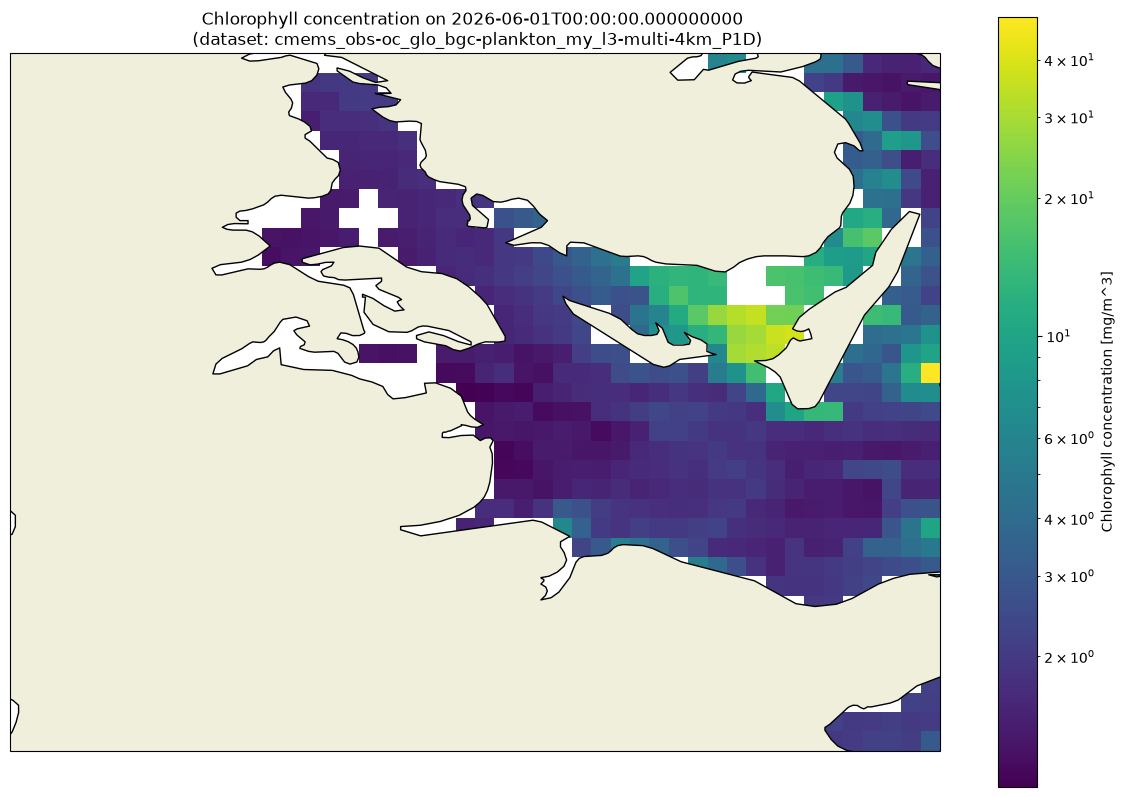

In [ ]:
## create our first map of total chlorophyll:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colors

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='10m', edgecolor='k', facecolor=cfeature.COLORS['land'])


fig = plt.figure(figsize=(15, 10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(land)

plt.pcolormesh(chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.CHL[0,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=colors.LogNorm()) # log-normalise color scale

plt.title(f"Chlorophyll concentration on {chl_ds.time[0].values} \n (dataset: {dsname})")

plt.colorbar(label='Chlorophyll concentration [mg/m^3]')
plt.show()

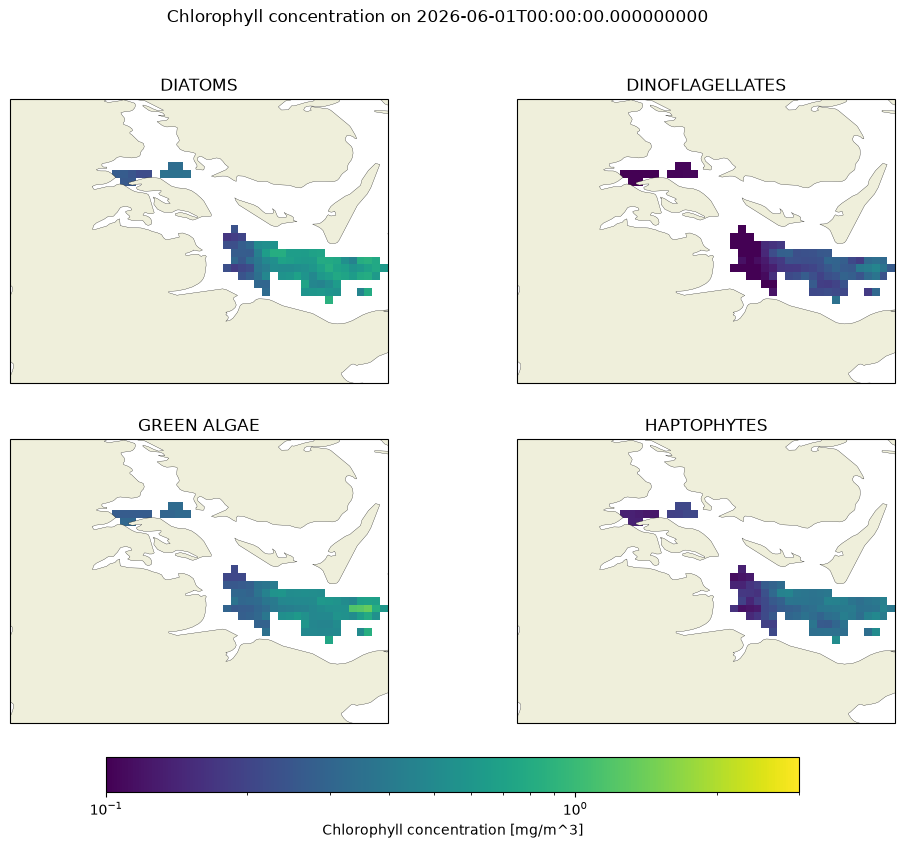

In [ ]:
# plot PFT chlorophyll for selected groups: 


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

fig.suptitle(f"Chlorophyll concentration on {chl_ds.time[0].values}")

# log-normalise color scale; apply to all colormesh calls to ensure same colorbar scale
norm = colors.LogNorm(vmin = 0.1, vmax = 3) 


m = axs[0,0].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.DIATO[0,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[0,0].add_feature(land, linewidth=0.2)
axs[0,0].set_title("DIATOMS")

axs[0,1].add_feature(land, linewidth=0.2)
axs[0,1].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.DINO[0,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[0,1].set_title("DINOFLAGELLATES")


axs[1,0].add_feature(land, linewidth=0.2)
axs[1,0].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.GREEN[0,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[1,0].set_title("GREEN ALGAE")

axs[1,1].add_feature(land, linewidth=0.2)
axs[1,1].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.HAPTO[0,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[1,1].set_title("HAPTOPHYTES")

fig.colorbar( # add a colorbar
    m,
    ax=axs,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05,
    label='Chlorophyll concentration [mg/m^3]'
)

plt.show()



In [28]:
## extracting data for a specific location and time series plot:

# e.g. Kiel Leuchtturm: 54.499199, 10.274029

lh_lat = 54.499199
lh_lon = 10.274029

point = chl_ds.sel(latitude=lh_lat, longitude=lh_lon, method='nearest')
point


<xarray.Dataset> Size: 1kB
Dimensions:              (time: 10)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2026-06-01 ... 2026-06-10
    latitude             float32 4B 54.48
    longitude            float32 4B 10.27
Data variables: (12/21)
    CHL                  (time) float32 40B ...
    CHL_uncertainty      (time) float64 80B ...
    DIATO                (time) float32 40B ...
    DIATO_uncertainty    (time) float64 80B ...
    DINO                 (time) float32 40B ...
    DINO_uncertainty     (time) float64 80B ...
    ...                   ...
    PICO_uncertainty     (time) float64 80B ...
    PROCHLO              (time) float32 40B ...
    PROCHLO_uncertainty  (time) float64 80B ...
    PROKAR               (time) float32 40B ...
    PROKAR_uncertainty   (time) float64 80B ...
    flags                (time) int8 10B ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_resolution:        P1D
    time_coverage_start:             2026-03-01T19:48:26Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0
    copernicusmarine_version:        2.4.1

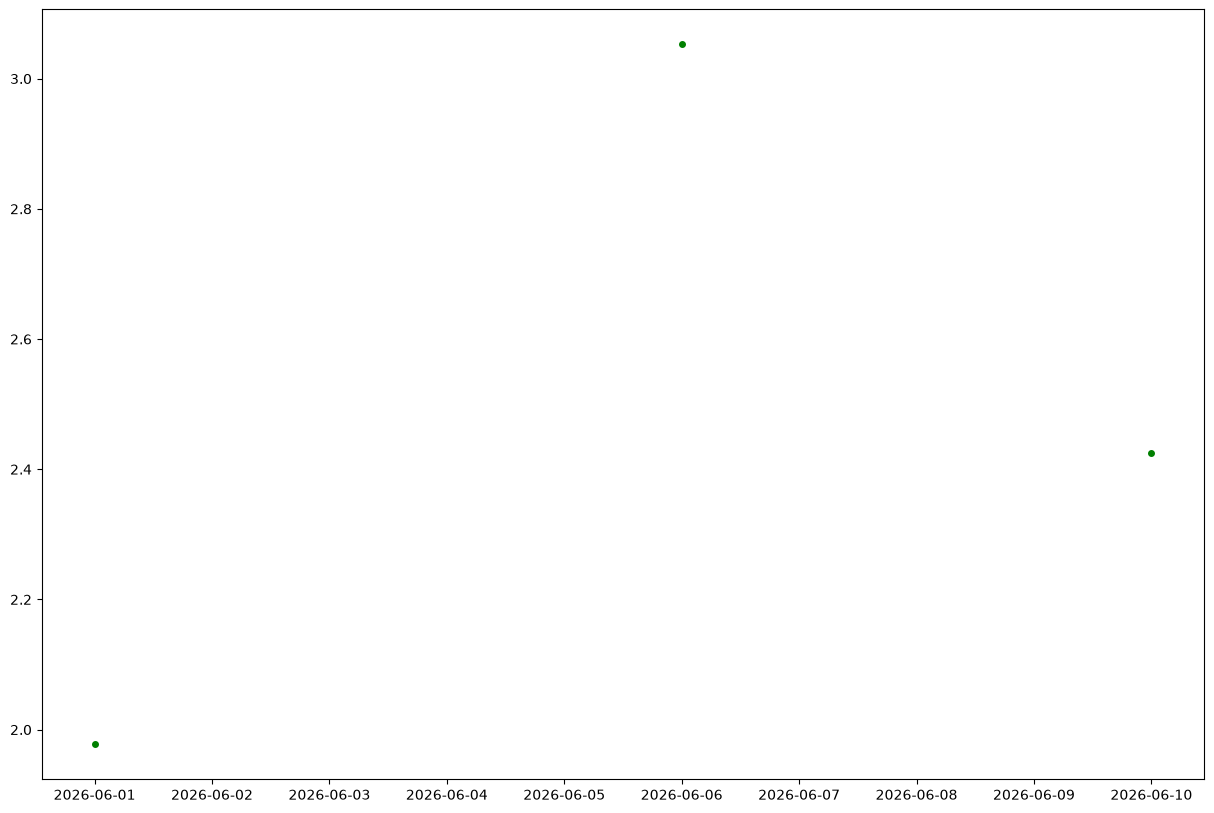

In [36]:
# easy scatter plot of total chlorophyll at this location over time:

fig = plt.figure(figsize=(15, 10))

# plt.scatter(point.time, point.CHL, color='green', label='Total chlorophyll')
plt.plot(point.time, point.CHL, color='green', label='Total chlorophyll',
          linewidth=2, marker='o', markersize=4)
